# 02 — ML baseline: Stage I lung cancer vs control from ELSA methylation

**Input:** `notebooks/data/`, built by `scripts/07_ml_dataset.py`.

| file | content |
|---|---|
| `X_methylation.tsv` | sample × region methylation fraction (0–1), low-depth values = NaN |
| `X_coverage.tsv` | methylation calls per sample × region |
| `samples.tsv` | labels + clinical / technical covariates |
| `regions.tsv` | all 2473 ELSA regions with QC stats and kept / dropped flag |
| `dataset_info.json` | build parameters and counts |

> **Read this first.** The current dataset has **9 samples** (5 control, 4 cancer) and
> ~2,450 features. Any performance number here has an enormous confidence interval and
> is **not evidence** of a working classifier. The goal of this notebook is a
> *leakage-safe scaffold* that runs unchanged once the full primary cohort
> (460 samples) is processed — only `COHORT_FILE` in `scripts/utils.py` changes.

**Leakage rules followed below**
- Imputation, scaling and feature selection happen **inside** each CV fold (sklearn `Pipeline`).
- The published classifier output (`predicted`) is not in the data at all.
- Covariates (age, gender, batch) are *checked* for confounding, never used as features here.

In [1]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, balanced_accuracy_score
from sklearn.model_selection import StratifiedKFold, cross_val_predict, permutation_test_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=UserWarning)
# SelectKBest: regions constant within a training fold give F = 0/0 (harmless).
warnings.filterwarnings("ignore", message="invalid value encountered in divide")

SEED = 42

# Works whether Jupyter was started in the project root or in notebooks/
ROOT = Path.cwd() if (Path.cwd() / "scripts").exists() else Path.cwd().parent
DATA_DIR = ROOT / "notebooks/data"
OUT_DIR = ROOT / "results/ml"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Fixed colors: class identity and model identity never change between plots.
CLASS_COLORS = {0: "#2a78d6", 1: "#eb6834"}          # control, cancer
CLASS_NAMES = {0: "Control", 1: "Stage I cancer"}
MODEL_COLORS = ["#2a78d6", "#1baf7a", "#eda100", "#e87ba4"]   # models, in order; orange stays "cancer"
MUTED = "#8a8985"

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": "#e6e5e1",
    "grid.linewidth": 0.8,
    "axes.axisbelow": True,
    "lines.linewidth": 2,
})

print(ROOT)

/home/ubuntu/ctdna-methylation-ml


## 1. Load and align

In [2]:
X = pd.read_csv(DATA_DIR / "X_methylation.tsv", sep="\t", index_col="sample_id")
coverage = pd.read_csv(DATA_DIR / "X_coverage.tsv", sep="\t", index_col="sample_id")
samples = pd.read_csv(DATA_DIR / "samples.tsv", sep="\t").set_index("sample_id")
regions = pd.read_csv(DATA_DIR / "regions.tsv", sep="\t").set_index("region_id")
info = json.loads((DATA_DIR / "dataset_info.json").read_text())

# Hard alignment checks — a silent row mismatch would invalidate everything.
samples = samples.loc[X.index]
assert X.index.equals(coverage.index) and X.columns.equals(coverage.columns)
assert X.columns.isin(regions.index[regions["kept"]]).all()
assert X.stack().dropna().between(0, 1).all()

y = samples["ml_label"].astype(int)

print(f"Samples : {X.shape[0]}   Features: {X.shape[1]}")
print(f"Labels  : " + ", ".join(f"{CLASS_NAMES[k]}={v}" for k, v in y.value_counts().sort_index().items()))
print(f"Missing : {X.isna().mean().mean() * 100:.3f}% (imputed inside CV)")
print(f"Built   : {info['created_utc']}  params={info['params']}")

Samples : 9   Features: 2452
Labels  : Control=5, Stage I cancer=4
Missing : 0.073% (imputed inside CV)
Built   : 2026-10-05T10:18:01+00:00  params={'min_depth': 20, 'max_missing': 0.2}


## 2. Confounder check

If a technical or demographic variable separates the classes, a model can learn
*that* instead of cancer methylation. With 9 samples this is very likely by chance —
check it before trusting anything.

In [3]:
for col in ["submission_series", "gender", "model_group", "stage"]:
    print(pd.crosstab(samples[col], y.map(CLASS_NAMES)), "\n")

numeric = ["age", "median_region_depth", "dna_input_ng", "mean_region_methylation"]
rows = []
for col in numeric:
    a = samples.loc[y == 0, col].astype(float)
    b = samples.loc[y == 1, col].astype(float)
    p = stats.mannwhitneyu(a, b).pvalue if len(a) and len(b) else np.nan
    rows.append({"variable": col, "control_median": a.median(), "cancer_median": b.median(), "mann_whitney_p": p})

pd.DataFrame(rows).round(4)

ml_label           Control  Stage I cancer
submission_series                         
SRR151                   2               0
SRR998                   3               4 

ml_label  Control  Stage I cancer
gender                           
F               4               1
M               1               3 

ml_label     Control  Stage I cancer
model_group                         
SBT                3               3
TV                 2               1 

ml_label  Control  Stage I cancer
stage                            
Benign          2               0
Healthy         3               0
IA              0               2
IB              0               2 



,variable,control_median,cancer_median,mann_whitney_p
0,age,55.0000,58.0000,0.4127
1,median_region_depth,1488.0000,1323.0000,0.9048
2,dna_input_ng,22.8000,23.9250,0.3893
3,mean_region_methylation,0.0784,0.0823,0.5556


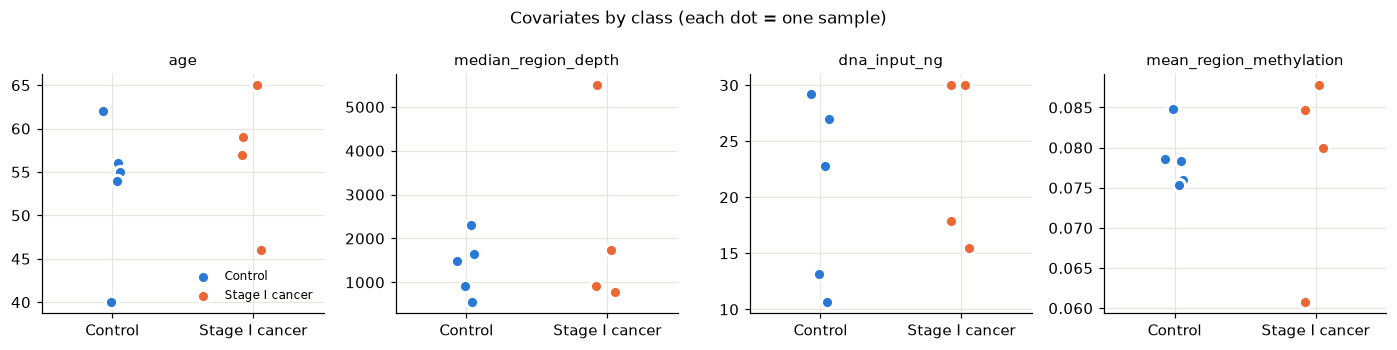

In [4]:
fig, axes = plt.subplots(1, len(numeric), figsize=(3.2 * len(numeric), 3.2))

for ax, col in zip(axes, numeric):
    for label in (0, 1):
        vals = samples.loc[y == label, col].astype(float)
        jitter = np.random.default_rng(SEED + label).uniform(-0.08, 0.08, len(vals))
        ax.scatter(np.full(len(vals), label) + jitter, vals, s=64,
                   color=CLASS_COLORS[label], edgecolor="white", linewidth=2, zorder=3,
                   label=CLASS_NAMES[label])
    ax.set_xticks([0, 1], [CLASS_NAMES[0], CLASS_NAMES[1]])
    ax.set_xlim(-0.5, 1.5)
    ax.set_title(col, fontsize=10)

axes[0].legend(frameon=False, fontsize=8, loc="best")
fig.suptitle("Covariates by class (each dot = one sample)", fontsize=11)
fig.tight_layout()
plt.show()

## 3. Models and cross-validation

All models are full pipelines, so every preprocessing step is refit on the training
part of each fold only.

- **Dummy** — predicts class prior; the AUC = 0.5 reference.
- **LogReg L2** — median impute → standardize → strongly regularized logistic regression.
- **LogReg + top-k** — adds univariate ANOVA selection of *k* regions *inside* the fold.
- **Random forest** — median impute → 300 trees, balanced class weights.

**CV scheme.** Stratified K-fold, K = min(5, smallest class size), repeated with
different shuffles. For each repeat, out-of-fold probabilities for *all* samples are
pooled and one AUC is computed (per-fold AUCs on 2–3 test samples are too coarse).
The spread across repeats shows CV instability — **not** a confidence interval for
new patients.

In [5]:
N_REPEATS = 20
TOP_K = min(100, X.shape[1])

n_splits = int(min(5, y.value_counts().min()))
assert n_splits >= 2, "Need at least 2 samples per class."

def imputer():
    return SimpleImputer(strategy="median", keep_empty_features=True)

models = {
    "Dummy": Pipeline([
        ("impute", imputer()),
        ("clf", DummyClassifier(strategy="prior")),
    ]),
    "LogReg L2": Pipeline([
        ("impute", imputer()),
        ("scale", StandardScaler()),
        ("clf", LogisticRegression(C=0.1, max_iter=5000, class_weight="balanced")),
    ]),
    f"LogReg + top-{TOP_K}": Pipeline([
        ("impute", imputer()),
        ("select", SelectKBest(f_classif, k=TOP_K)),
        ("scale", StandardScaler()),
        ("clf", LogisticRegression(C=0.1, max_iter=5000, class_weight="balanced")),
    ]),
    "Random forest": Pipeline([
        ("impute", imputer()),
        ("clf", RandomForestClassifier(n_estimators=300, class_weight="balanced",
                                       random_state=SEED, n_jobs=-1)),
    ]),
}

print(f"CV: {n_splits}-fold stratified x {N_REPEATS} repeats, n={len(y)}")

CV: 4-fold stratified x 20 repeats, n=9


In [6]:
def repeated_oof(model, X, y, n_splits, n_repeats, seed=SEED):
    # Out-of-fold P(cancer) for every sample, for each CV repeat.
    probs = np.zeros((n_repeats, len(y)))
    for r in range(n_repeats):
        cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed + r)
        probs[r] = cross_val_predict(clone(model), X, y, cv=cv, method="predict_proba")[:, 1]
    return probs

oof = {name: repeated_oof(m, X, y, n_splits, N_REPEATS) for name, m in models.items()}

rows = []
for name, probs in oof.items():
    aucs = np.array([roc_auc_score(y, p) for p in probs])
    bacc = np.array([balanced_accuracy_score(y, p >= 0.5) for p in probs])
    rows.append({
        "model": name,
        "auc_mean": aucs.mean(),
        "auc_p2.5": np.percentile(aucs, 2.5),
        "auc_p97.5": np.percentile(aucs, 97.5),
        "balanced_acc_mean": bacc.mean(),
    })

cv_summary = pd.DataFrame(rows).set_index("model").round(3)
cv_summary

,auc_mean,auc_p2.5,auc_p97.5,balanced_acc_mean
model,,,,
Dummy,0.425,0.425,0.425,0.425
LogReg L2,0.262,0.100,0.402,0.465
LogReg + top-100,0.283,0.074,0.476,0.438
Random forest,0.361,0.187,0.501,0.454


### How to read these numbers at n = 9

Expect AUCs **below 0.5**, including for the Dummy model. This is a known small-sample
CV artifact ("anti-learning"), not a reversed biological signal: holding out one of only
four cancers shifts the training class balance and class centroid *away* from the
held-out sample, so it looks more like the other class. The Dummy row is therefore the
real reference for this CV scheme, not 0.5.

The artifact fades as n grows. At this size the table only proves that the
pipeline runs end to end without leakage.

### Permutation test

Refit the main model on label-shuffled data. If the real AUC is not clearly above the
permuted distribution, the model has learned nothing beyond chance.

With 9 samples there are only C(9,4) = 126 distinct labelings, so the smallest
attainable p-value is about 0.008. Here each test fold holds a single cancer, so a fold
AUC is 0, 0.5 or 1 and the anti-learning effect above can push the real score to 0.

In [ ]:
MAIN_MODEL = "LogReg L2"
N_PERMUTATIONS = 200

score, perm_scores, p_value = permutation_test_score(
    clone(models[MAIN_MODEL]), X, y,
    cv=StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED),
    scoring="roc_auc",
    n_permutations=N_PERMUTATIONS,
    random_state=SEED,
    n_jobs=-1,
)

print(f"{MAIN_MODEL}: mean fold AUC = {score:.3f}, permutation p = {p_value:.3f}")

fig, ax = plt.subplots(figsize=(6, 3.4))
ax.hist(perm_scores, bins=20, color=MUTED, edgecolor="white", linewidth=2, label="Shuffled labels")
ax.axvline(score, color=CLASS_COLORS[1], linewidth=2, label=f"Real labels (AUC {score:.2f})")
ax.set_xlabel("Mean fold ROC AUC")
ax.set_ylabel("Permutations")
ax.set_title(f"Permutation test — {MAIN_MODEL} (p = {p_value:.3f})", fontsize=11)
ax.legend(frameon=False, fontsize=9)
fig.tight_layout()
plt.show()

### ROC — out-of-fold probabilities averaged over repeats

In [ ]:
fig, ax = plt.subplots(figsize=(5.2, 5))
ax.plot([0, 1], [0, 1], linestyle="--", color=MUTED, linewidth=1.5, label="Chance")

mean_oof = {}
real_models = [name for name in oof if name != "Dummy"]
for color, name in zip(MODEL_COLORS, real_models):
    p = oof[name].mean(axis=0)
    mean_oof[name] = p
    fpr, tpr, _ = roc_curve(y, p)
    ax.plot(fpr, tpr, color=color, label=f"{name} (AUC {roc_auc_score(y, p):.2f})",
            drawstyle="steps-post")

ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
ax.set_aspect("equal")
ax.set_title(f"Out-of-fold ROC (n={len(y)})", fontsize=11)
ax.legend(frameon=False, fontsize=8, loc="lower right")
fig.tight_layout()
plt.show()

oof_table = samples[["run_id", "ml_label", "stage", "submission_series"]].copy()
for name, p in mean_oof.items():
    oof_table[f"p_cancer__{name}"] = p.round(3)
oof_table

## 4. Descriptive: which regions differ?

**Descriptive only.** Univariate tests on all samples (no CV). With 9 samples and
~2,450 tests, expect nothing to survive FDR correction; rankings are hypotheses to
revisit on the full cohort.

In [ ]:
ctrl = X[y == 0]
canc = X[y == 1]

t_stat, t_p = stats.ttest_ind(canc, ctrl, axis=0, equal_var=False, nan_policy="omit")

diff = pd.DataFrame({
    "control_mean": ctrl.mean(),
    "cancer_mean": canc.mean(),
    "delta": canc.mean() - ctrl.mean(),
    "welch_t": np.asarray(t_stat),
    "p_value": np.asarray(t_p),
})
diff["fdr_bh"] = stats.false_discovery_control(diff["p_value"].fillna(1.0), method="bh")
diff = diff.join(regions[["chrom", "start0", "end", "median_depth"]])
diff = diff.sort_values("p_value")

print(f"Regions with FDR < 0.05: {(diff['fdr_bh'] < 0.05).sum()} / {len(diff)}")
diff.head(20).round(4)

In [ ]:
fig, ax = plt.subplots(figsize=(6.5, 4))
top = diff.head(20).index
ax.scatter(diff["delta"], -np.log10(diff["p_value"]), s=10, color=MUTED, alpha=0.5, linewidth=0,
           label="All regions")
ax.scatter(diff.loc[top, "delta"], -np.log10(diff.loc[top, "p_value"]), s=36,
           color=CLASS_COLORS[1], edgecolor="white", linewidth=1.5, label="Top 20 by p-value")
ax.axvline(0, color=MUTED, linewidth=1)
ax.set_xlabel("Methylation difference (cancer − control)")
ax.set_ylabel("−log10 p (Welch t, unadjusted)")
ax.set_title("Region-level differences (descriptive, not FDR-significant)", fontsize=11)
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()

In [ ]:
# Largest logistic-regression coefficients from a fit on ALL samples.
# Also descriptive: with p >> n many coefficient sets fit equally well.
full_fit = clone(models[MAIN_MODEL]).fit(X, y)
coef = pd.Series(full_fit.named_steps["clf"].coef_[0], index=X.columns, name="coef")

top_coef = (
    coef.to_frame()
    .assign(abs_coef=coef.abs())
    .join(diff[["delta", "p_value"]])
    .join(regions[["chrom", "start0", "end"]])
    .sort_values("abs_coef", ascending=False)
    .head(20)
)
top_coef.round(4)

## 5. Save results

In [ ]:
cv_summary.to_csv(OUT_DIR / "cv_summary.tsv", sep="\t")
oof_table.to_csv(OUT_DIR / "oof_predictions.tsv", sep="\t")
diff.to_csv(OUT_DIR / "region_differences.tsv", sep="\t")
top_coef.to_csv(OUT_DIR / "top_logreg_coefficients.tsv", sep="\t")

pd.Series({
    "model": MAIN_MODEL,
    "mean_fold_auc": score,
    "permutation_p": p_value,
    "n_permutations": N_PERMUTATIONS,
    "n_samples": len(y),
    "n_features": X.shape[1],
}).to_csv(OUT_DIR / "permutation_test.tsv", sep="\t", header=False)

sorted(p.name for p in OUT_DIR.iterdir())

## 6. Next steps (for the full cohort)

1. Process the full primary cohort (`metadata/primary_cohort_stage1_vs_control.tsv`,
   460 samples), point `COHORT_FILE` in `scripts/utils.py` to it, rerun
   `python main.py` and this notebook.
2. Use the paper's split: `model_group == "SBT"` for training/CV, `"TV"` as a
   **held-out** test set, touched once at the end.
3. Tune hyperparameters (C, k, trees) with **nested** CV only.
4. Re-check confounding with `submission_series` (SRR151 vs SRR998 differ in class
   balance), depth and age; consider stratifying CV or adjusting.
5. Report sensitivity at fixed high specificity (e.g. 95%) as in screening studies,
   with bootstrap CIs on the held-out set.